<img src='http://hilpisch.com/taim_logo.png' width="350px" align="right">

# Artificial Intelligence in Finance

## Superintelligence

Dr Yves J Hilpisch | The AI Machine

http://aimachine.io | http://twitter.com/dyjh

In [1]:
%pip install gym
%pip install -U gymnasium


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import  gymnasium as gym
import numpy as np
import pandas as pd
np.random.seed(100)

In [3]:
import warnings
warnings.simplefilter('ignore')

In [4]:
env = gym.make('CartPole-v0')

In [5]:
# env.seed()

In [6]:
action_size = env.action_space.n
action_size

np.int64(2)

In [7]:
[env.action_space.sample() for _ in range(10)]

[np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0)]

In [8]:
state_size = env.observation_space.shape[0]
state_size

4

In [9]:
state = env.reset()
state  # [cart position, cart velocity, pole angle, pole angular velocity]

(array([-0.03455611, -0.03772638,  0.01883977,  0.01033979], dtype=float32),
 {})

In [10]:
state, reward, done, trunc, _ = env.step(env.action_space.sample())
state, reward, done, trunc, _

(array([-0.03531064, -0.23311338,  0.01904656,  0.30890685], dtype=float32),
 1.0,
 False,
 False,
 {})

In [11]:
%%time
data = pd.DataFrame()
state = env.reset()
length = []
for run in range(25000):
    done = False
    prev_state = env.reset()[0]
    treward = 1
    results = []
    while not done:
        action = env.action_space.sample()
        state, reward, done, trunc, _ = env.step(action)
        results.append({'s1': prev_state[0], 's2': prev_state[1],
                        's3': prev_state[2], 's4': prev_state[3],
                        'a': action, 'r': reward})
        treward += reward if not done else 0
        prev_state = state
    if treward >= 110:
        data = pd.concat((data, pd.DataFrame(results)))
        length.append(treward)

CPU times: user 10.7 s, sys: 43.9 ms, total: 10.7 s
Wall time: 11.2 s


In [12]:
np.array(length).mean()

np.float64(116.0)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 348 entries, 0 to 117
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   s1      348 non-null    float32
 1   s2      348 non-null    float32
 2   s3      348 non-null    float32
 3   s4      348 non-null    float32
 4   a       348 non-null    int64  
 5   r       348 non-null    float64
dtypes: float32(4), float64(1), int64(1)
memory usage: 13.6 KB


In [14]:
data.tail()

,s1,s2,s3,s4,a,r
113,0.488182,-0.652246,0.083508,1.576807,1,1.0
114,0.475137,-0.458213,0.115044,1.311294,0,1.0
115,0.465973,-0.654588,0.141270,1.637658,1,1.0
116,0.452881,-0.461378,0.174023,1.392124,1,1.0
117,0.443653,-0.268796,0.201866,1.158520,1,1.0


In [15]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [16]:
from pylab import plt
plt.style.use('seaborn-v0_8')
%matplotlib inline

In [17]:
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(100)

E0000 00:00:1775344495.652206   14939 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775344495.656720   14939 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [18]:
# from tensorflow.python.framework.ops import disable_eager_execution
# disable_eager_execution()
import tensorflow as tf
print(tf.executing_eagerly())  # True


True


In [19]:
from keras.layers import Dense
from keras.models import Sequential

In [20]:
model = Sequential()
model.add(Dense(64, activation='relu',
                input_dim=env.observation_space.shape[0]))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['acc'])

In [21]:
%%time
model.fit(data[['s1', 's2', 's3', 's4']], data['a'],
          epochs=25, verbose=False, validation_split=0.2)

CPU times: user 2.4 s, sys: 219 ms, total: 2.62 s
Wall time: 3.59 s


In [22]:
res = pd.DataFrame(model.history.history)
res.tail(3)

,acc,loss,val_acc,val_loss
22,0.615108,0.645221,0.642857,0.647932
23,0.622302,0.644377,0.642857,0.647346
24,0.618705,0.643596,0.642857,0.646798


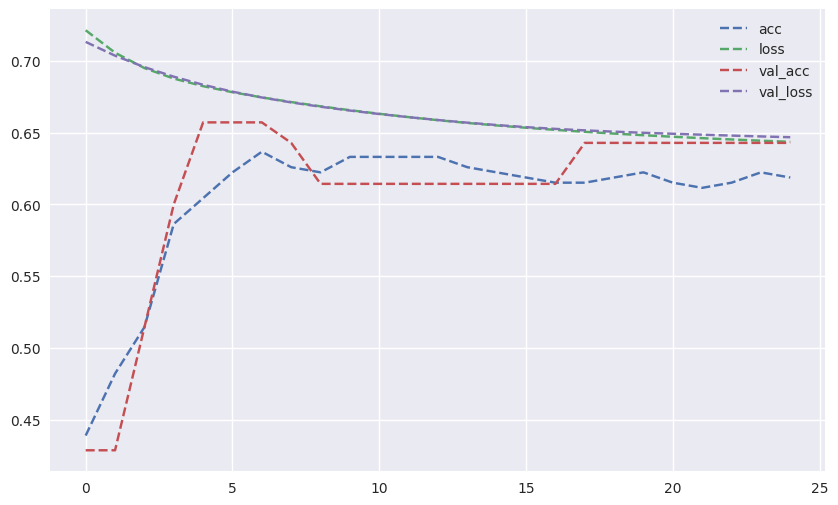

In [23]:
res.plot(figsize=(10, 6), style='--');

In [24]:
def epoch():
    print('|', end='')
    done = False
    state = env.reset()[0]
    trunc = False
    treward = 0
    while not done and not trunc:
        action = np.where(model.predict(np.atleast_2d(state))[0][0] > 0.5, 1, 0)
        state, reward, done, trunc, _ = env.step(action)
        treward += reward if not done else 0
    return treward

In [25]:
epoch()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

200.0

In [ ]:
%%time
res = np.array([epoch() for _ in range(100)])
print()
res

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

In [ ]:
res.mean()

200.0

<img src='http://hilpisch.com/taim_logo.png' width="350px" align="right">

<br><br><br><a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:ai@tpq.io">ai@tpq.io</a>